# Project 1

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, chisquare, kstest, expon, uniform
from scipy import stats
import scipy


## Task 1

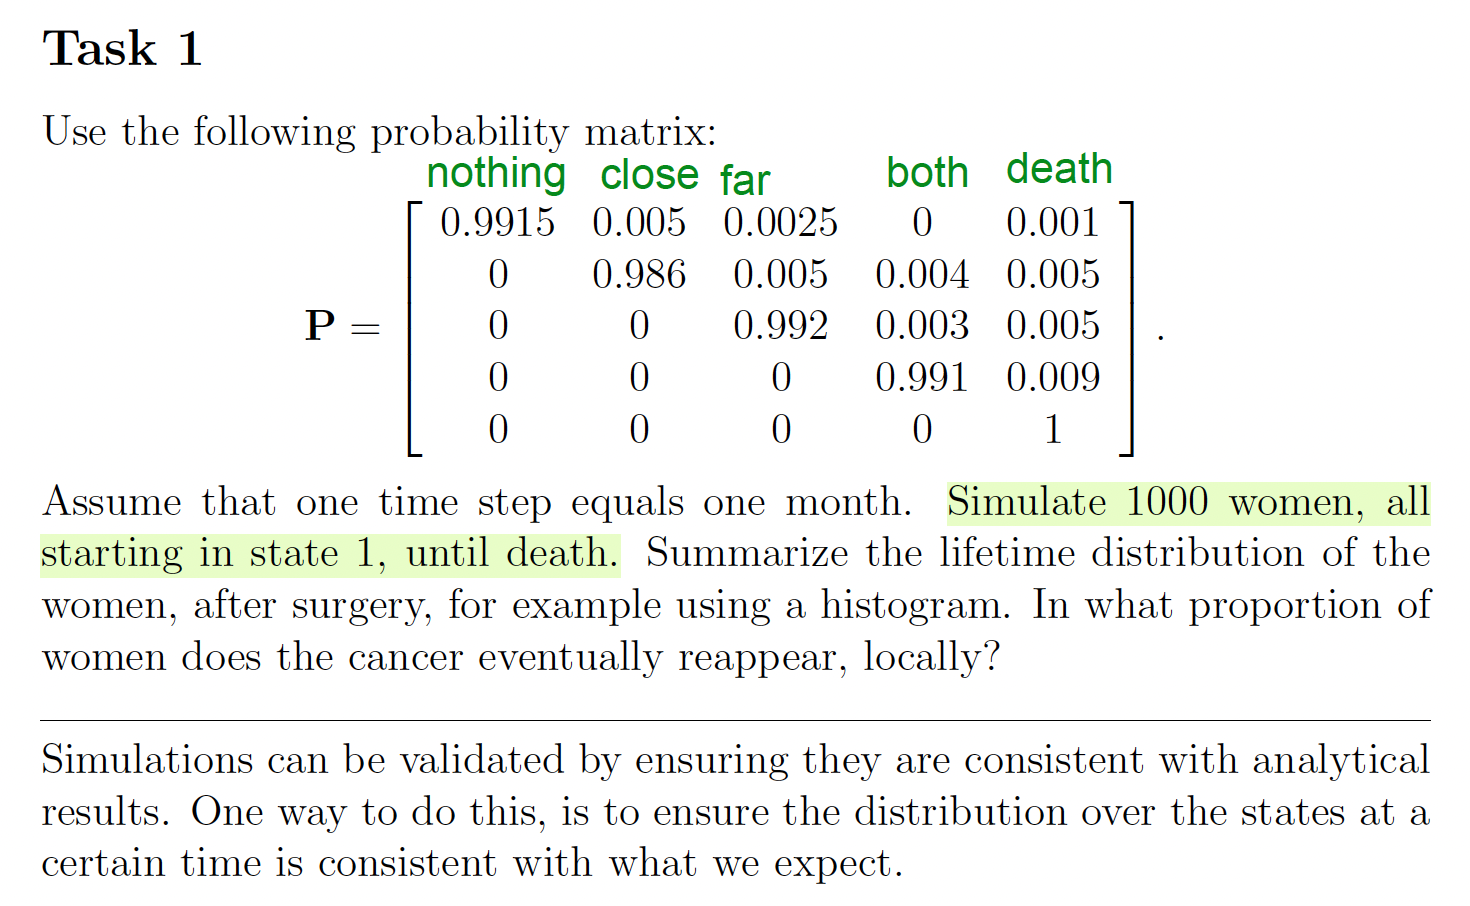

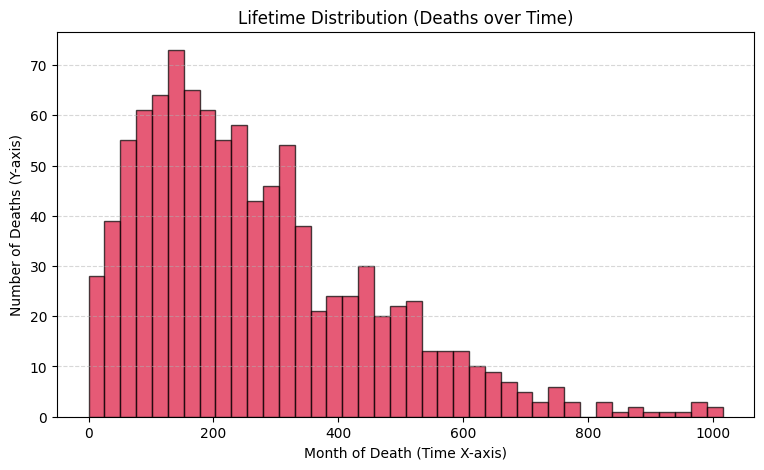

In [6]:
sim_num = 1000
months = 1000000

P = np.array([[0.9915,0.005, 0.0025, 0, 0.001],
              [0, 0.986, 0.005, 0.004, 0.005],
              [0,0,0.992,0.003,0.005],
              [0,0,0,0.991,0.009],
              [0,0,0,0,1]])

def Task1_sim(sim_num, months, P):
    states = np.array([0,1,2,3,4])
    #Alle 1000 women start in state 0
    women_states_index = np.zeros(sim_num, dtype=int)

    # Track if a specific woman has ever had local cancer
    has_local_cancer = np.zeros(sim_num, dtype=bool)

    death_months = np.zeros(sim_num, dtype=int)

    current_state = np.array([sim_num,0,0,0,0])

    pt_list = []
    for t in range(months):
        for woman in range(sim_num):
            current_state = women_states_index[woman]
            #if she is dead we skipp her
            if current_state == 4:
                continue
            choice = np.random.choice(states, p=P[current_state])
            women_states_index[woman] = choice
            #if she gets stage 1 we make it true that she has local cancer.
            if choice == 1:
                has_local_cancer[woman] = True

            #If she is dies now this is her death month
            if choice == 4:
                death_months[woman] = t 

        counts = np.bincount(women_states_index, minlength=5)
        pt_list.append(counts)
        #We break before time if weveryone is dead
        if np.all(counts == np.array([0, 0, 0, 0, sim_num])):
            break
    
    women_getting_local_cancer=np.sum(has_local_cancer)

    return pt_list, women_getting_local_cancer, death_months


# Run simulation
pt_list, local_cancer, death_months = Task1_sim(sim_num, months, P)

# --- PLOT THE HISTOGRAM ---
plt.figure(figsize=(9, 5))
# death_months tells us exactly when each of the 1000 women died
plt.hist(death_months, bins=40, color='crimson', edgecolor='black', alpha=0.7)

plt.title("Lifetime Distribution (Deaths over Time)")
plt.xlabel("Month of Death (Time X-axis)")
plt.ylabel("Number of Deaths (Y-axis)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Task 2

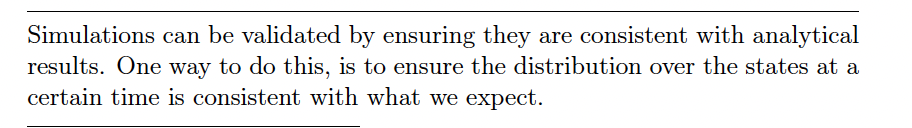
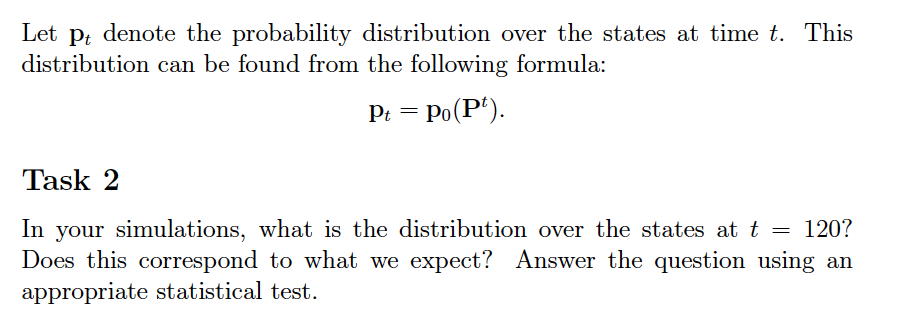


In [12]:
#--------Theoretical
np.random.seed(42)
P = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]
])
p0 = np.array([1000,0,0,0,0])

months = 120

def sim_woman_lifetimes(P, months, p0):
    death_rate_at_t = []
    T = []
    p_list = [p0]
    p=p0
    for t in range(months):
        p = p @ P
        death_rate_at_t.append(p[-1])
        T.append(t)
        p_list.append(p)
        if p[-1]>=999.5:
            break
    return death_rate_at_t, p_list, T

death_rate_at_t, p_list, T = sim_woman_lifetimes(P, months, p0)
p_list[-1]
    

array([359.02626821, 158.95603979, 166.08689731,  67.74149395,
       248.18930075])

In [13]:
np.random.seed(42)
pt_list, local_cancer, death_months = Task1_sim(sim_num, 120, P)

pt_list[-1]

array([370, 148, 177,  73, 232])

In [17]:

observed = pt_list[-1] 

expected = p_list[-1] 

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi-square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Chi-square Statistic: 3.2718
p-value: 0.5134


## Task 3

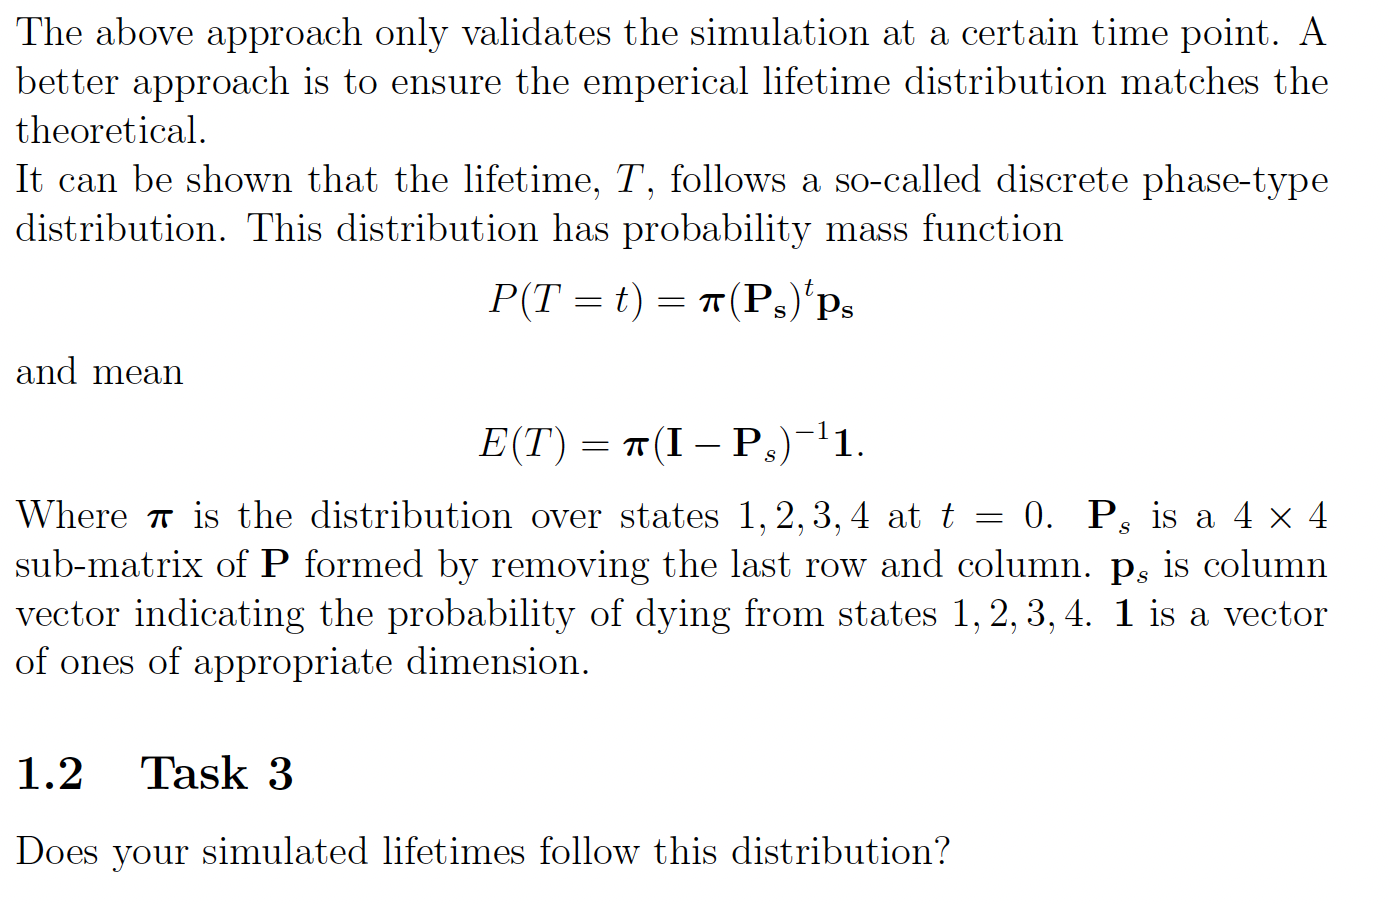

[1.         1.029      1.057676   ... 0.00736905 0.00731733 0.00726596]


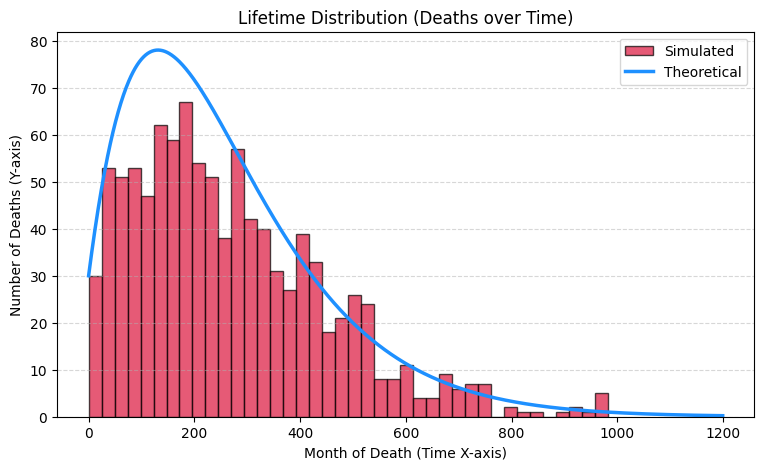

In [58]:
sim_num = 1000
months = 1200

Pi= np.array([sim_num, 0,0,0])
Ps = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000],
    [0.0000, 0.9860, 0.0050, 0.0040],
    [0.0000, 0.0000, 0.9920, 0.0030],
    [0.0000, 0.0000, 0.0000, 0.9910]
])
ps= np.array([0.0010, 0.0050, 0.0050, 0.0090])

#Theoretical lifetime distribution
def prop_mass_T(t, Pi, Ps, ps):
    Ps_t = np.linalg.matrix_power(Ps, t)
    return Pi@ Ps_t @ps

def mean_T(t, Pi, Ps):
    return Pi@np.linalg.inv(np.eye(4)-Ps )@np.ones(4)

theo_mass = []
for t in range(months):
    theo_mass.append(prop_mass_T(t, Pi, Ps, ps))

theo_mass = np.array(theo_mass)

print(theo_mass)

pt_list, local_cancer, death_months = Task1_sim(sim_num, months, P)

# --- PLOT THE HISTOGRAM & THEORETICAL LINE ---
plt.figure(figsize=(9, 5))
plt.hist(death_months, bins=40, color='crimson', edgecolor='black', alpha=0.7, label='Simulated')

bin_width = 1200 / 40  
plt.plot(range(1200), theo_mass * bin_width, color='dodgerblue', linewidth=2.5, label='Theoretical')

plt.title("Lifetime Distribution (Deaths over Time)")
plt.xlabel("Month of Death (Time X-axis)")
plt.ylabel("Number of Deaths (Y-axis)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


## Task 4

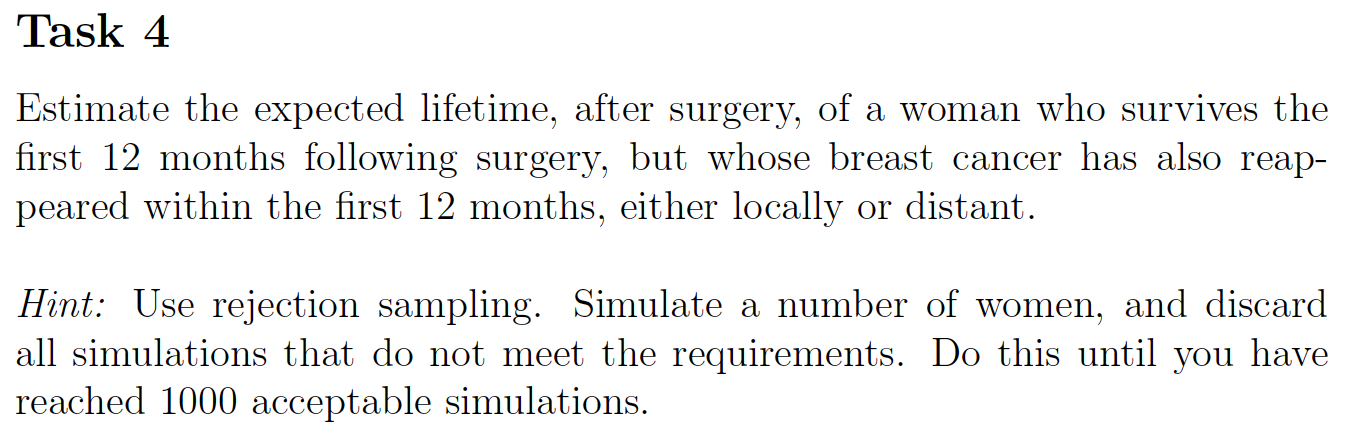

In [51]:
# we have this code for simulating one woman
def simulate_a_woman(X0,P):
    #X0 is initial state
    # P is probability matrix 
    states = np.array([0,1,2,3,4])
    States = []
    current_state =X0

    while current_state !=4:
        current_state = np.random.choice(states, p=P[current_state])
        States.append(current_state)

    #returns the list of all the states a woman is in in her lifetime, lenght of that is amount of months she lives 
    return np.array(States)

#Rejection sampling 
def rejection_sampling_women(simulate_a_woman, P):
    Women = []
    np.random.seed(42)
    while len(Women)!=1000:
        #we simulate a woman
        X = simulate_a_woman(0,P)
        #if she has had local cancer in the first 12 months AND lives past 12 months we accept
        if (1 in X[:12]) and (len(X)>12):
            Women.append(X) 
        #if she has had distant cancer in the first 12 months AND lives past 12 months we accept
        elif (2 in X[:12]) and (len(X)>12):
            Women.append(X)
        #otherwise we reject. 
    return Women

Women = rejection_sampling_women(simulate_a_woman, P)

In [42]:
length = []
for woman in Women:
    length.append(len(woman))
mean_life = np.mean(length)
#Expected lifetime
mean_life

np.float64(178.715)

## Task 5

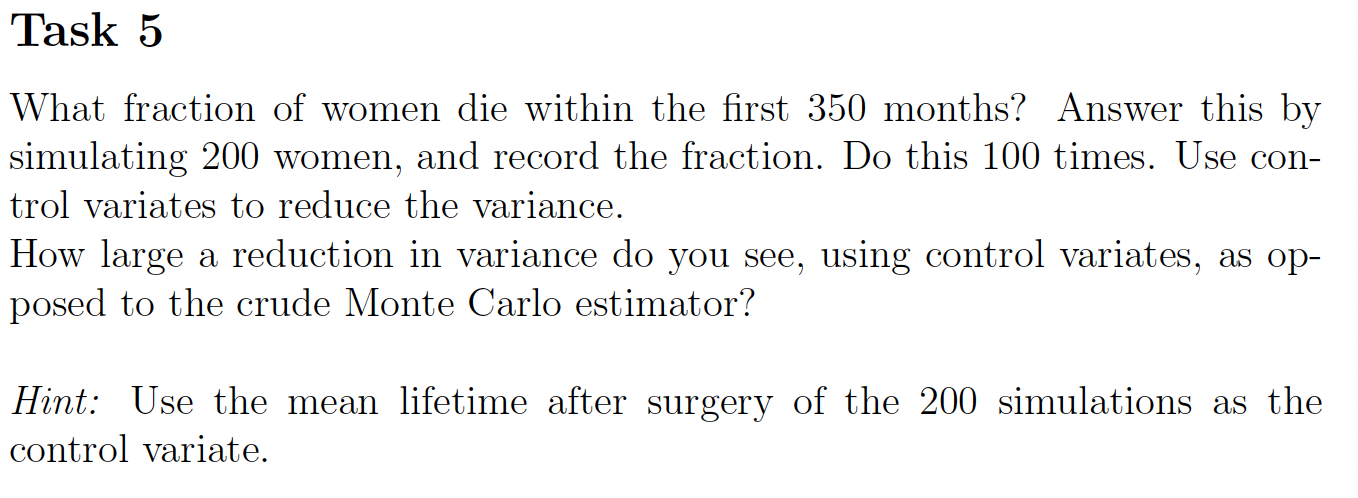

In [50]:
np.random.seed(42)
simulated_women = 200
simulation_times = 100
#First we do it the monte carlo way
def crude_montecarlo(simulated_women, simulation_times):
    fractions = []
    for t in range(simulation_times):
        frac = 0
        for i in range(simulated_women):
            woman = simulate_a_woman(0,P)
            if  len(woman) < 350:
                frac += 1
        fraction = frac / simulated_women
        fractions.append(fraction)
    return np.mean(fractions), np.var(fractions, ddof = 1)
    

fractions = crude_montecarlo(simulated_women, simulation_times)
fractions


(np.float64(0.73645), np.float64(0.0012945934343434348))

In [66]:
# Xi må være vores gamle indikator variabel
# Zi er en livstid, og så er mu gennemsnit af de 200.
np.random.seed(42)

# i redefine pi so its percent wise based so in stead of 1000 its 1
Pi = np.array([1,0,0,0])

def control_variate(n, Ps, Pi, P):
    # n is simulation times

    Y_mean = []

    # Expected value
    m = np.linalg.inv(np.eye(4)-Ps)
    mu = Pi@m@np.ones(4)
    mu

    
    for i in range(n):
        life_time = []
        indicator = []
        for _ in range(200):
            X = simulate_a_woman(0,P)
            life_time.append(len(X))
            if len(X)<350: 
                indicator.append(1)
            else: 
                indicator.append(0)
        life_time = np.array(life_time)
        indicator=np.array(indicator)
        c = -np.cov(indicator,life_time)[0,1]/np.var(life_time)
        Y = indicator+c*(life_time-mu)
        Y_mean.append(np.mean(Y))
    return np.mean(Y_mean), np.var(Y_mean,ddof=1)

control_variate(simulation_times, Ps, Pi, P)



(np.float64(0.7358703481080613), np.float64(0.0003179218932220689))

We do see a reduction in variance with control variate

## Task 6

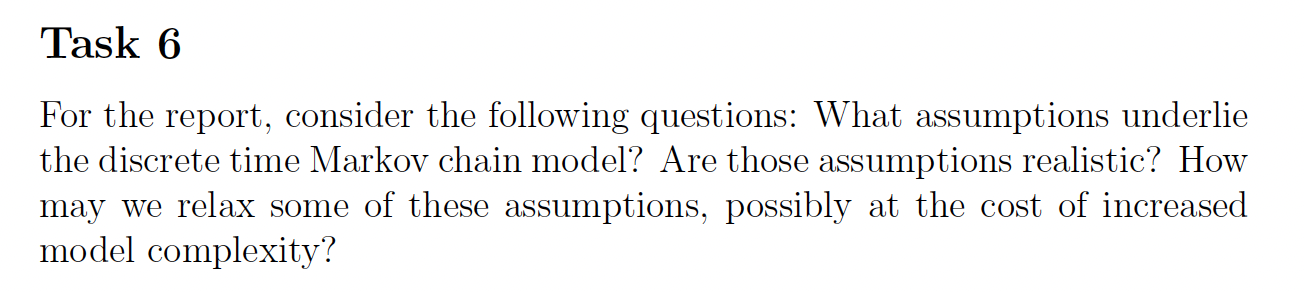

We have discussed this in the report

## Task 7

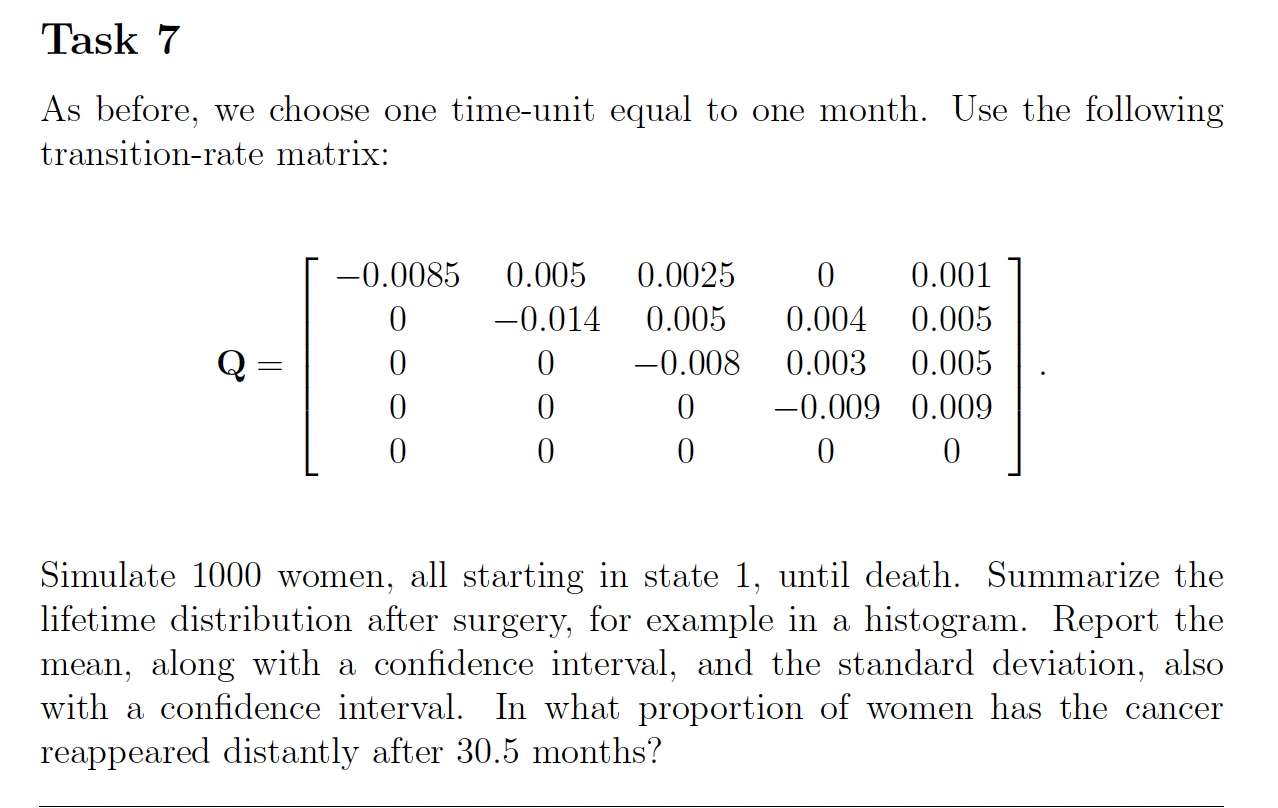

In [84]:
Q = np.array([[-0.0085, 0.005, 0.0025, 0, 0.001],
               [0, -0.014, 0.005, 0.004, 0.005], 
               [0, 0, -0.008, 0.003, 0.005],
               [0, 0, 0, -0.009, 0.009],
               [0, 0, 0, 0, 0]])

np.random.seed(42)
# we have this code for simulating one woman
def sim__continous_woman(Q):
    state = 0
    time = 0
    pasted_states = [(time, state)]

    while state != 4:
        #We now work with a rate for change not a probability, becuase its continous
        # state i is exponentially distributed with rate -qii
        #so the rate is the diagonal element
        rate = -Q[state, state]

        sojourn_time = np.random.exponential(1/rate)
        time += sojourn_time

        #probability of moving to another state is then (other state/rate)
        #Getting Q[state] gives us the ros so all probs of that state
        probs = Q[state].copy()
        #the probability of stating in exatcly same place is 0 because we move with a rate after the exponential waiting time
        probs[state] = 0

        #this is the prob of a new state as given
        probs = probs/rate

        #pick a state based on this
        state = np.random.choice(np.arange(5), p = probs)
        pasted_states.append((time,state))
    return pasted_states

#so after time 55 we have pasted on to state 4.
sim__continous_woman(Q)



[(0, 0), (55.20801058551283, np.int64(4))]

Life time mean 256.3715684046518
Life time confidence interval for mean [(np.float64(244.30943097040762), np.float64(268.43370583889595))]
Life time std 194.37915621555038
Life time confidence interval for std [(np.float64(186.2176320670264), np.float64(203.29442568598935))]
Fraction of distant cancer again 0.084


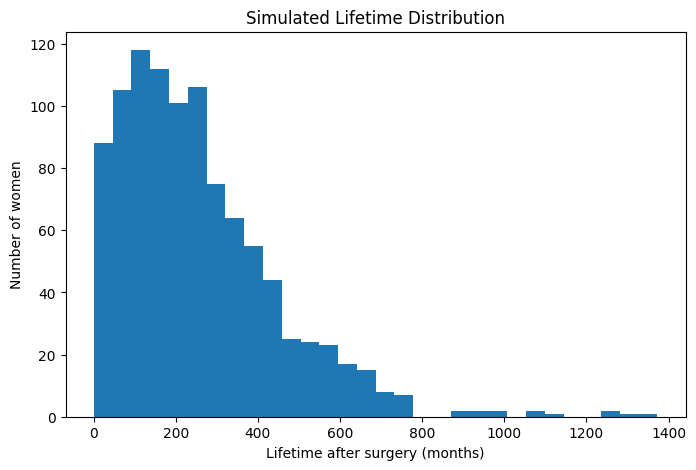

In [91]:
np.random.seed(42)
n = 1000
life_time_rate= []
#standard cofidence interval code
def confidence_interval_95(results):
    results = np.asarray(results)
    n = len(results)

    mean = np.mean(results)
    std = np.std(results, ddof=1)

    t_crit = stats.t.ppf(0.975, df=n-1)

    margin = t_crit * std / np.sqrt(n)

    return (mean - margin, mean + margin)

def confidence_interval_std_95(results):
    results = np.asarray(results)
    n = len(results)

    s = np.std(results, ddof=1)

    chi2_lower = stats.chi2.ppf(0.025, df=n-1)
    chi2_upper = stats.chi2.ppf(0.975, df=n-1)

    lower = np.sqrt((n - 1) * s**2 / chi2_upper)
    upper = np.sqrt((n - 1) * s**2 / chi2_lower)

    return (lower, upper)

#The amount of women where the cancer reappers after 30.5 moths.
reapar_dist = 0 
for i in range(n):
    X = sim__continous_woman(Q)
    life_time_rate.append(X[-1][0])
    for time,s in X:
        #checking if there for all times under 30.5 alkso is apperance of state distance and distance plus local.
        if time <= 30.5 and s in [2,3]:
            reapar_dist += 1 
            break

lifetimes_rate = np.array(life_time_rate)
mean_life =  np.mean(lifetimes_rate)
conf_mean_life = confidence_interval_95(lifetimes_rate)
std_life = np.std(lifetimes_rate,  ddof=1)
cond_std_life = confidence_interval_std_95(lifetimes_rate)
dist_cancer_again = reapar_dist/n

print(f"Life time mean {mean_life}")
print(f"Life time confidence interval for mean [{conf_mean_life}]")
print(f"Life time std {std_life}") 
print(f"Life time confidence interval for std [{cond_std_life}]")
print(f"Fraction of distant cancer again {dist_cancer_again}")

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(lifetimes_rate, bins=30)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Simulated Lifetime Distribution")
plt.show()


# Task 8

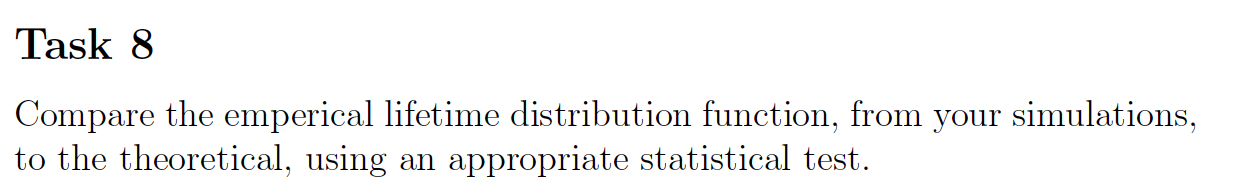

In [96]:
Qs = np.array([
    [-0.0085, 0.0050, 0.0025, 0.0000],
    [ 0.0000,-0.0140, 0.0050, 0.0040],
    [ 0.0000, 0.0000,-0.0080, 0.0030],
    [ 0.0000, 0.0000, 0.0000,-0.0090]
])

p0 = np.array([1,0,0,0])

# calculating the empiroical lifetime distribution. 

def theoretical_lifetime(Qs, p0, t):
    #only takes one argument so dont know how to factor in the time. 
    expQs= scipy.linalg.expm(Qs*t)
    FT = 1 - p0 @ expQs @ np.ones(len(p0))
    return FT

FT_list = []

#create lin space ranging from zero to longest living woman
max_t = np.max(life_time_rate)
#life_time rate is a long list with life times for a woman follows by lifetimes for the next woman followed by the next woman and so on
# so wher elifetimes are the times whe moves states. so the max number in this list marks the maximum time a woman reaches before whe moves to the ding state and her lifetime ends. 
times = np.linspace(0, max_t)
for t in times:
    FT_list.append(theoretical_lifetime(Qs, p0, t))


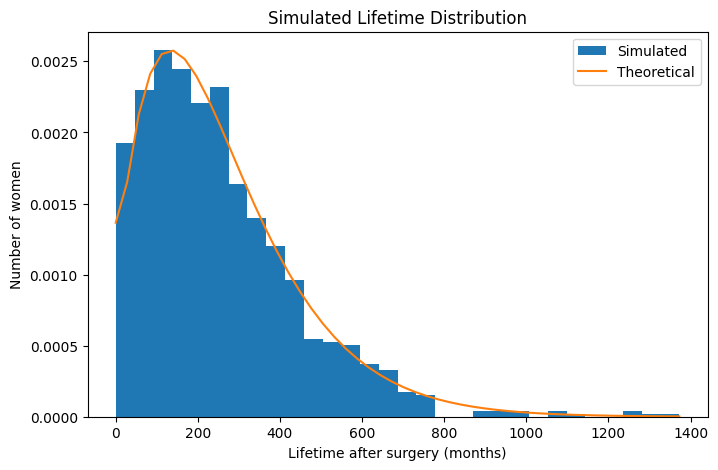

In [97]:
f_t = np.gradient(FT_list,times)

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(lifetimes_rate, bins=30, density=True, label = "Simulated")
plt.plot(times,f_t, label = "Theoretical")
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Simulated Lifetime Distribution")
plt.legend()
plt.show()

In [98]:
# chi square
bins = np.linspace(0, np.max(life_time_rate), 10)
obs_counts, _ = np.histogram(life_time_rate, bins=bins)

# Compute expected counts 
expected_counts = []

for i in range(len(bins) - 1):
    t1, t2 = bins[i], bins[i+1]

    F1 = theoretical_lifetime(Qs, p0, t1)
    F2 = theoretical_lifetime(Qs, p0, t2)

    expected_counts.append(len(life_time_rate) * (F2 - F1))

expected_counts = np.array(expected_counts)

mask = expected_counts >= 5

obs_counts = obs_counts[mask]
expected_counts = expected_counts[mask]

chi2_stat = np.sum((obs_counts - expected_counts)**2 / expected_counts)

df = len(obs_counts) - 1

p_value = 1 - stats.chi2.cdf(chi2_stat, df=df)

print("Chi-square:", chi2_stat)
print("p-value:", p_value)

Chi-square: 7.233608036637046
p-value: 0.20383822622164127


# Task 9

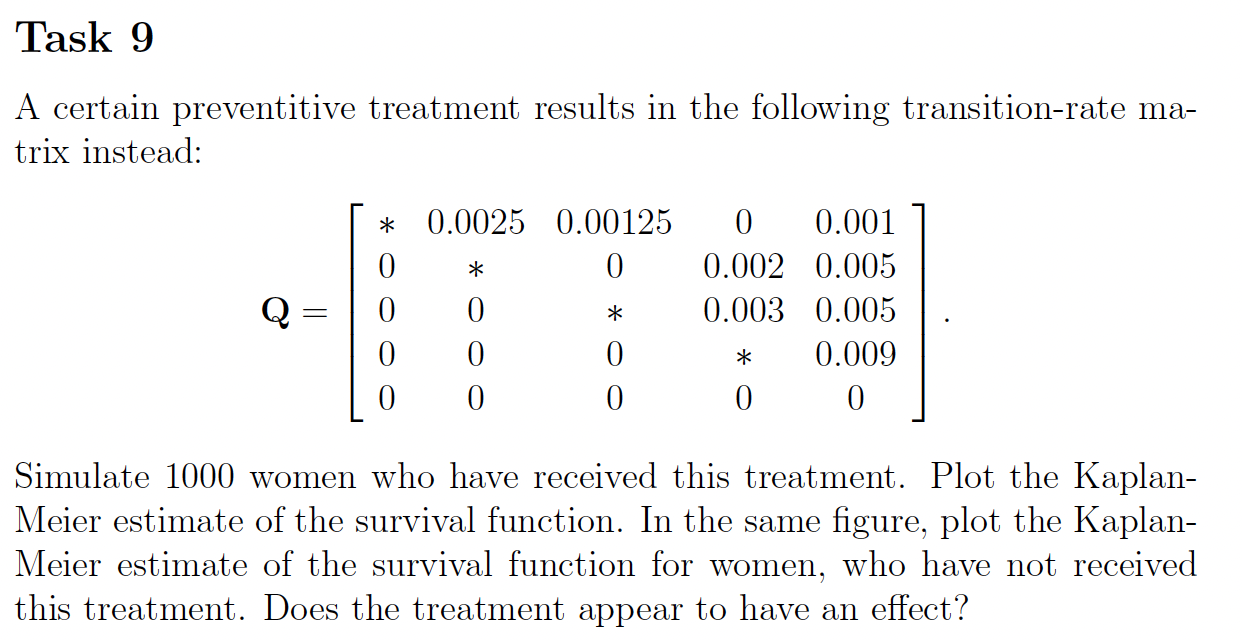

In [131]:
Q_missing = np.array([[0, 0.0025, 0.00125, 0, 0.001],
                      [0, 0, 0, 0.002, 0.005],
                      [0, 0, 0, 0.003, 0.005],
                      [0, 0, 0, 0, 0.009],
                      [0, 0, 0, 0, 0]])

def constructing_new_Q(Q): 
    for i in range(len(Q)):
        diag_element = -(Q[i][0]+Q[i][1]+ Q[i][2] + Q[i][3] + Q[i][4])
        Q[i][i] = diag_element
    return Q

Q9 = constructing_new_Q(Q_missing)
Q9


array([[-0.00475,  0.0025 ,  0.00125,  0.     ,  0.001  ],
       [ 0.     , -0.007  ,  0.     ,  0.002  ,  0.005  ],
       [ 0.     ,  0.     , -0.008  ,  0.003  ,  0.005  ],
       [ 0.     ,  0.     ,  0.     , -0.009  ,  0.009  ],
       [ 0.     ,  0.     ,  0.     ,  0.     , -0.     ]])

In [103]:
sim__continous_woman(Q9)

[(0, 0),
 (79.9885239213956, np.int64(1)),
 (214.4354605605856, np.int64(3)),
 (268.7772319289134, np.int64(4))]

In [132]:
#simulating a 1000 women who recives the new Q9 treatment
np.random.seed(42)
n = 1000
np.random.rand(42)
life_time_9 = []
for i in range(n):
    X = sim__continous_woman(Q9)
    #the last element in the times list for a woman is her lifetime
    life_time_9.append(X[-1][0])
life_time_9 = np.array(life_time_9)
#list of time each woman dies
life_time_9 

array([7.36709925e+00, 1.09737065e+02, 6.65545879e+02, 5.90546194e+02,
       1.91800929e+02, 2.61181218e+01, 3.55686072e+02, 8.84194453e+01,
       1.63107092e+01, 3.12261329e+02, 4.92059204e+02, 5.10252749e+02,
       5.48123759e+02, 2.05614335e+02, 4.15961030e+02, 9.98253847e+00,
       4.78330726e+02, 3.98567463e+02, 2.11261935e+02, 6.61417933e+02,
       3.46810167e+02, 1.17530137e+02, 3.58700995e+02, 9.28373309e+01,
       7.07255600e+02, 9.51525261e+01, 7.89186485e+02, 2.04934889e+02,
       3.69784713e+02, 1.05278933e+03, 1.14438123e+02, 2.23162924e+02,
       8.73808546e+01, 4.55928157e+02, 6.87885517e+02, 5.44461136e+02,
       2.75241271e+02, 1.72756543e+02, 6.81222028e+02, 6.07187887e+02,
       2.11599787e+02, 1.14739423e+02, 4.43852174e+02, 2.20794487e+02,
       2.72179552e+02, 1.07849408e+03, 4.56316310e+02, 2.02145377e+02,
       5.93912242e+02, 5.20858991e+02, 1.17671216e+02, 6.97628521e+02,
       3.45530348e+02, 3.83010340e+02, 3.14069391e+02, 3.31573989e+02,
      

In [133]:
np.random.seed(42)
# In order to plot Kaplan Meier estimate of the suvival function we start by making dt
# dt is the number of eomen who have died at time t.
def d_t(life_time, t):
    #died at time t 
    died =life_time<=t
    return np.sum(died)

# Now we create the suvival function
def suvival_Kaplan_Meier(N, life_times): 
    max_t = np.max(life_times)
    times = np.linspace(0,max_t)
    S_t = []
    for t in times: 
        S_t.append((N-d_t(life_times,t))/N)
    return S_t

S_t = suvival_Kaplan_Meier(1000, life_time_9)

#compare with the old Q that was no tratment
#simulating a 1000 women who recives the new Q9 treatment
n = 1000
np.random.rand(42)
life_time_old = []
for i in range(n):
    X = sim__continous_woman(Q)
    #the last element in the times list for a woman is her lifetime
    life_time_old.append(X[-1][0])
life_time_old = np.array(life_time_old)
#list of time each woman dies
S_t_old = suvival_Kaplan_Meier(1000, life_time_old)


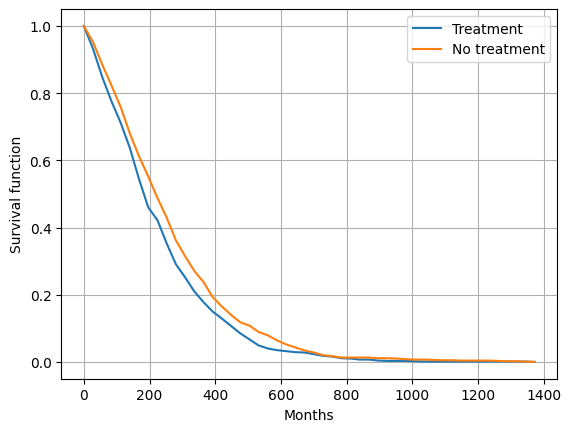

In [134]:
plt.plot(times, S_t, label= "Treatment")
plt.plot(times, S_t_old, label= "No treatment")
plt.xlabel("Months")
plt.ylabel("Survival function")
plt.grid()
plt.legend()
plt.show()

So oddly enough it looks like you will die soner with the new treatment

# Task 11

We did not make the optional task 10

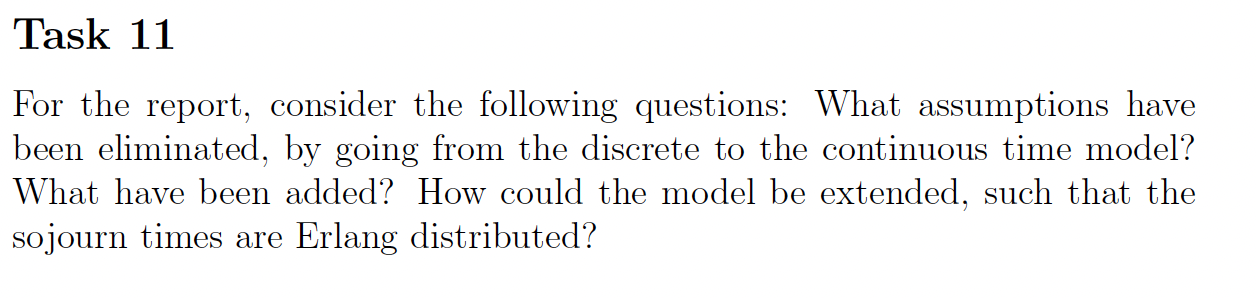

We have elimintaed the assumtion that a change in cancer diagnostic only happens once a month. 

The sojoun time being exponential is an. assumption

We coud do the sojorn times erlang distributed. 

## Task 12

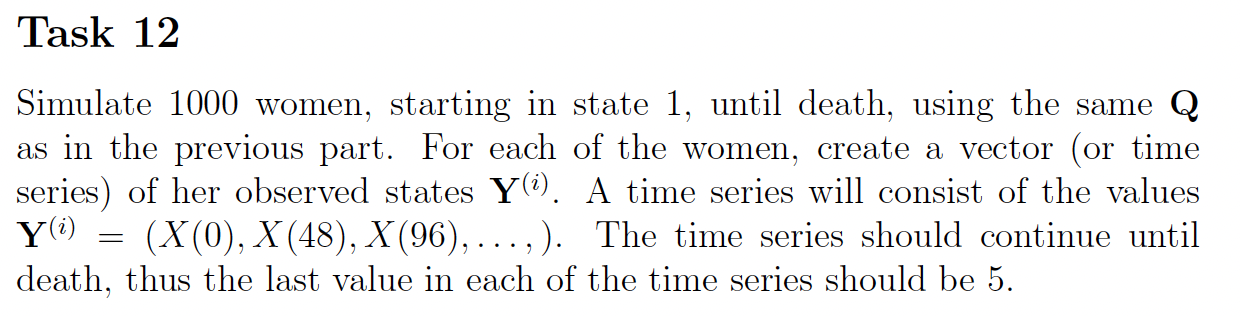

In [150]:
np.random.seed(42)
n = 1000

Q = np.array([
    [-0.0085,  0.0050,  0.0025, 0.0000, 0.0010],
    [ 0, -0.0140,  0.0050, 0.0040, 0.0050],
    [ 0,  0, -0.0080, 0.0030, 0.0050],
    [ 0,  0,  0, -0.0090, 0.0090],
    [ 0,  0,  0, 0, 0]
])

observation_increments = 48

def compute_time_series(n, Q, obs_t= 48):
    time_series_Ys = []  
    for _ in range(n):
        Yi = []
        X = sim__continous_woman(Q)
        # i is every 48 months
        i = 0

        for t in np.arange(0, X[-1][0] + obs_t, 48):
            #len(X) is the amount of transistions in states a woman makes doing her life
            #if i + 1 is larger than len(X) it means the woman has died before the next consultation at time i + 1

            #X[i + 1][0] checks if the change happens witin this docors visit or the next.it should be for the one it belongs to.
            while i + 1 < len(X) and X[i + 1][0] <= t:
                i += 1

            Yi.append(X[i][1])

            if Yi[-1] == 4: # if woman dead stop 
                break
        time_series_Ys.append(Yi)
    return time_series_Ys
    




In [151]:
time_series_Ys = compute_time_series(n, Q, obs_t= 48)
time_series_Ys

[[0, 0, np.int64(4)],
 [0, 0, 0, 0, np.int64(4)],
 [0, 0, 0, np.int64(4)],
 [0, 0, 0, 0, 0, np.int64(2), np.int64(4)],
 [0, 0, np.int64(1), np.int64(2), np.int64(3), np.int64(3), np.int64(4)],
 [0, np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(4)],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  np.int64(2),
  np.int64(3),
  np.int64(3),
  np.int64(4)],
 [0, np.int64(4)],
 [0, np.int64(2), np.int64(4)],
 [0,
  0,
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(4)],
 [0, 0, 0, 0, 0, 0, 0, np.int64(4)],
 [0, 0, 0, np.int64(4)],
 [0,
  np.int64(2),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(4)],
 [0, np.int64(1), np.int64(4)],
 [0, np.int64(4)],
 [0, 0, 0, 0, np.int64(4)],
 [0, 0, 0, 0, np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(4)],
 [0, 0, 0, 0, 0, np.int64(2), np.int64(3), np.int64(4)],
 [0,
  0,
  0,
  0,
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int6

# Task 13

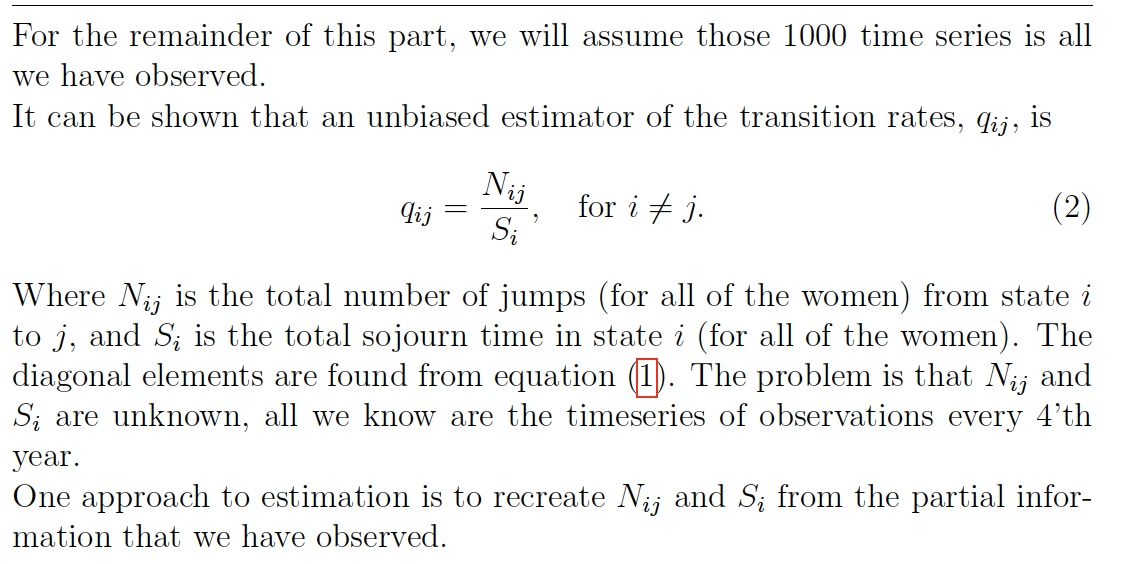

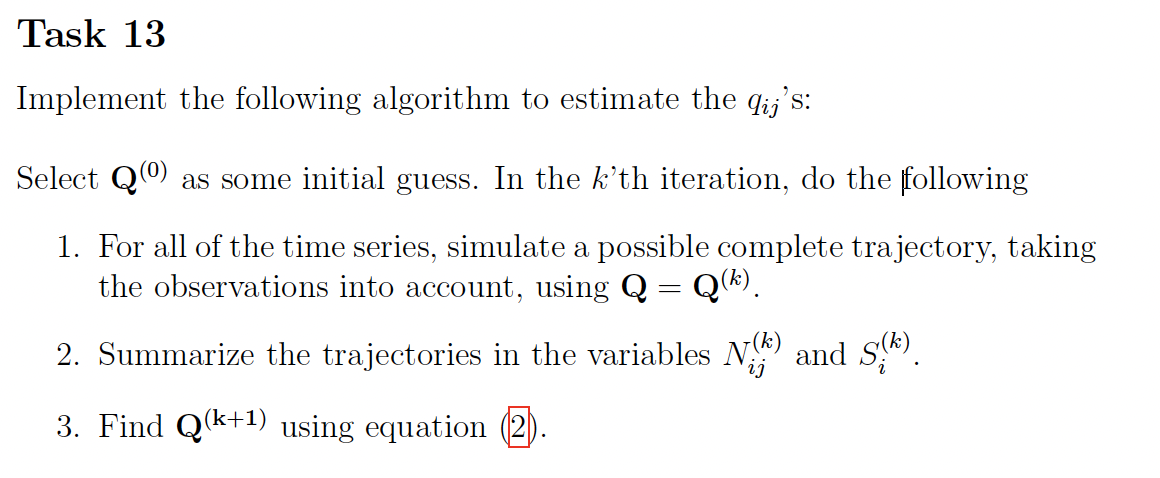

In [152]:
# For the k'th iteration we do the following: 

# 1) for all of the time series we simulate a possible complete trajectory, taking the observarions into account using the Q at time k. (Q_k)

def sim_MC(X0, X_end, Q_k, t,  obs_t = 48):
    state = X0
    #why multiply should it not be plus?
    time = obs_t * t
    end_time = obs_t * (t + 1)

    passed_states = [(time, state)]

    while True: 
        #the rate qii
        rate = -Q_k[state, state]

        if state == 4: #stop when reaching death state
            break
        
        sojoun_time = np.random.exponential(1 / rate)

        #if next time somthing happens is after woman has died we break
        if time + sojoun_time > end_time:
            break

        time += sojoun_time

        #probability of moving to another state is then (other state/rate)
        #Getting Q[state] gives us the ros so all probs of that state
        probs = Q[state].copy()
        #the probability of stating in exatcly same place is 0 because we move with a rate after the exponential waiting time
        probs[state] = 0

        #this is the prob of a new state as given
        probs = probs/rate




In [153]:

def simulate_markov(X0, X_end, Q, t):

    state = X0
    time = 48 * t
    end_time = 48 * (t + 1)

    history = [(time, state)]

    while True:

        rate = -Q[state, state]

        if state == 4:  # No going on after death
            break

        wait = np.random.exponential(1 / rate)

        if time + wait > end_time:
            break

        time += wait

        probs = Q[state].copy()
        probs[state] = 0
        probs /= rate

        state = np.random.choice(len(Q), p=probs)

        history.append((time, state))

    # state at end_time
    if state == X_end:
        return history
    else:
        return False
    
def create_Q(maxiter, eps, Q0):
    Q = Q0
    k =0
    dif = np.inf

    while (k <= maxiter) and (dif >=eps):
        # create the full Markov chain for all women
        all_women = []
        for woman in Simulations: 
            history = [(0,0)]
            for t in range(len(woman[:-1])): 
                his_subset =simulate_markov(woman[t],woman[t+1],Q,t)
                while his_subset == False: 
                    his_subset =simulate_markov(woman[t],woman[t+1],Q,t)
                history.extend(his_subset[1:])
            all_women.append(history)

        N = np.zeros(np.shape(Q))
        S = np.zeros(np.shape(Q)[0])


        for path in all_women:
            for (t1, s1), (t2, s2) in zip(path[:-1], path[1:]):
                if s1 != s2:
                    N[s1, s2]+=1
                    duration = t2-t1
                    S[s1] +=duration
        
        for i in range(len(S)-1):
            N[i] = N[i]/S[i]

        diag_elements_add(N)

        dif = np.linalg.norm((Q-N),ord=np.inf)
        k+=1
        Q = N 

    return Q

In [154]:
Q0 = np.array([
    [-0.04, 0.01, 0.01, 0.01,   0.01],
    [0.0, -0.03,    0.01,     0.01, 0.01],
    [0.0, 0.0,    -0.02,     0.01, 0.01],
    [0.0, 0.0,    0.0,     -0.01,   0.01],
    [0.0, 0.0,    0.0,     0.0,   0.0]
])
np.random.seed(42)
create_Q(10000,10**(-3) , Q0)

NameError: name 'Simulations' is not defined